# E2: a fresh NL→FOL faithfulness test set (paused when the budget ran out)

This notebook demonstrates **`data.py`** from artifact `art_2OmxzMInZZJY`. The script builds **E2**, a fresh set for
confirming NL→FOL faithfulness results. E2 shares no sentences with dataset **E**, and its labels come from E's
byte-identical, frozen labeller. `data.py` itself does **no labelling and computes no metric**. It assembles the rows
from earlier pipeline steps into the `exp_sel_data_out` JSON format. Before it writes a row, it **re-checks the row
against the original public sources**:

| group | what is checked against the source |
|---|---|
| `e2_candidates` | the raw LLM output equals the **last** `generations.jsonl` record for (sentence, slot, prompt variant); `candidate_fol == normalise(raw)`; the text exists in MALLS / ProverQA |
| `e2_gold_as_system` | the candidate (the gold used as if it were a system's output) equals the source gold FOL |
| `e2_sentences` | the text and its gold FOL equal the source record |
| `e2_controls` | the parent row exists and the control is z3-equivalent to it (empty in this budget-stopped state) |
| `e2_panel_drift` | E's stored LLM-panel votes next to today's replayed votes, per calibration item and per track-H pair |

**State of the artifact:** the shared OpenRouter budget ran out part-way through the run. Only the 30-sentence
pilot was generated (300 candidates). The other 520 pre-registered sentences are `PENDING_GENERATION_BUDGET_STOP`. The
panel drift replay was also cut off, so the stop rule is still **UNDECIDED**.

**What this demo runs:** the original code, unchanged apart from where it reads its inputs. `mini_demo_data.json`
holds a curated slice of *every* input file that `data.py` reads:

- 6 pilot sentences (2 per fold: DT / L25 / EXC) with their 60 candidates and 6 gold-as-system rows
- 6 pending sentences
- 12 synthetic-gate calibration items and 4 track-H pairs
- only the MALLS / ProverQA source records, `generations.jsonl` records and panel-cache lines those rows need

The notebook reads those inputs from the loaded `data` dict instead of the artifact's `work/`, `temp/datasets/` and `raw/` folders.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports

This is the original import block of `data.py`. The original put `src/` and `labeller/` on `sys.path` and ran
`from normalise import normalise`. Here `normalise` is defined inline further down (a verbatim copy of
`src/normalise.py`), so those two path lines are dropped. `re` and `unicodedata` are needed by `normalise`.
`pandas` and `matplotlib` are used only by the results cell.

In [2]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

from loguru import logger

sys.setrecursionlimit(10000)

# needed by normalise() (copied from src/normalise.py)
import re
import unicodedata

# notebook-only: results table and plots
import pandas as pd
import matplotlib.pyplot as plt

## Load the demo data

The data loads from GitHub, and falls back to a local `mini_demo_data.json` if that fails. The file has one key per input of `data.py`:
`assembled_E2` (→ `work/assembled_E2.json`), `controls_E2`, `sources` (the five files in `temp/datasets/`),
`generations` (→ `raw/generations.jsonl`), `calibration_items`, `E_panel_cache` / `E2_panel_cache`
(→ `panel_cache.jsonl` of E and of E2) and `E_trackh_panel_rows` / `E2_trackh_panel_rows`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-4/dataset-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(data["metadata"]["n_examples"])

Curated demo slice of every input read by data.py (E2 NL->FOL faithfulness confirmation set). 6 pilot sentences (2 per fold E2_DT / E2_L25 / E2_EXC) with their 60 candidates and 6 gold-as-system rows, 6 pending (budget-stopped) sentences, 12 synthetic-gate calibration items and 4 track-H pairs, plus only the source, generation and panel-cache records those rows need.
{'e2_candidates': 60, 'e2_gold_as_system': 6, 'e2_sentences': 12, 'calibration_items': 12, 'trackh_pairs': 4}


## Configuration

`data.py` has no training loop, so its only tunables are the output size limit and how the mini and preview
variants are cut. For the demo, three knobs also choose how much of the bundled slice to process. The bundle
has 6 pilot sentences, 12 calibration items and 4 track-H pairs. The full artifact has 30 pilot sentences
(300 candidates), 550 sentences, 77 calibration items and 96 track-H pairs.

In [5]:
# --- demo subset size (the bundle holds 6 / 12 / 4; the full artifact 30 / 77 / 96) ---
N_PILOT_SENTENCES = 6    # pilot sentences whose candidates + gold-as-system rows are processed (full run: 30)
N_CALIB_ITEMS = 12       # synthetic-gate calibration items in the panel-drift group (full run: 77)
N_TRACKH_PAIRS = 4       # track-H real-error pairs in the panel-drift group (full run: 96)

# --- original data.py constants ---
LIMIT = 100 * 1000 * 1000   # max bytes of full_data_out.json before a split would be needed
MINI_N = 3                  # rows per group in mini_data_out.json (original: [:3])
PREVIEW_TRUNC = 200         # string truncation in preview_data_out.json (original: _trunc n=200)

## Paths, logger and constants

These are the same as the original, except that `ROOT` is a local output folder instead of the script's own directory. `TD`
(`temp/datasets`), `W` (`work`) and `E_DIR` (dataset E's workspace) are no longer read, because their files come from `data`.
`FORBIDDEN` lists keys that the output schema does not allow on a row. `Q_PREFIX` is the fixed ProverQA question stem,
which is stripped so that a conclusion sentence can be matched to its `conclusion_fol`.

In [6]:
ROOT = Path("e2_demo_out").resolve()
ROOT.mkdir(exist_ok=True)
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")
FORBIDDEN = {"split", "dataset", "context"}
Q_PREFIX = "Based on the above information, is the following statement true, false, or uncertain? "

## The frozen output normaliser (`src/normalise.py`, verbatim)

`data.py` checks that each stored `candidate_fol` equals `normalise(raw_output)[0]`. The normaliser maps
**surface syntax only** and never repairs meaning. It strips code fences and the `FOL:` prefix, keeps the first formula line, unwraps
LaTeX, maps ASCII/word connectives and quantifiers (`->`, `&`, `forall x.` …) to the Unicode notation the labeller's
parser reads, and folds diacritics on letters.

In [7]:
LATEX = [
    (r"\\text\{([^{}]*)\}", r"\1"), (r"\\mathrm\{([^{}]*)\}", r"\1"), (r"\\operatorname\{([^{}]*)\}", r"\1"),
    (r"\\forall\s*", "∀"), (r"\\exists\s*", "∃"), (r"\\land\b|\\wedge\b", "∧"), (r"\\lor\b|\\vee\b", "∨"),
    (r"\\neg\b|\\lnot\b", "¬"), (r"\\leftrightarrow\b|\\iff\b|\\Leftrightarrow\b", "↔"),
    (r"\\rightarrow\b|\\to\b|\\Rightarrow\b|\\implies\b", "→"), (r"\\oplus\b", "⊕"),
    (r"\\\(|\\\)|\\\[|\\\]|\$", ""), (r"\\[,;!: ]", " "),
]
WORDOPS = [
    (r"\bforall\s+([a-z][a-z0-9]*)\s*[.:]?", r"∀\1 "), (r"\ball\s+([a-z])\s*\.", r"∀\1 "),
    (r"\bexists\s+([a-z][a-z0-9]*)\s*[.:]?", r"∃\1 "), (r"\bexist\s+([a-z])\s*\.", r"∃\1 "),
    (r"<->|<=>|⟷|⇔|≡", "↔"), (r"->|=>|⟶|⇒|⊃", "→"), (r"&&|&", "∧"), (r"\|\||\|", "∨"),
    (r"\bxor\b|⊻", "⊕"), (r"\bnot\s+", "¬"), (r"[~!]|¬", "¬"), (r"\band\b", "∧"), (r"\bor\b", "∨"),
]


def normalise(raw: str | None) -> tuple[str, list[str]]:
    applied: list[str] = []
    if raw is None:
        return "", ["none"]
    s = raw.strip()
    if "```" in s:
        m = re.search(r"```(?:[a-zA-Z]*)\n?(.*?)```", s, re.S)
        if m:
            s = m.group(1).strip()
            applied.append("code_fence")
    m = re.search(r"FOL\s*[:：]\s*(.+)", s)
    if m:
        s = m.group(1)
        applied.append("fol_prefix")
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    if len(lines) > 1:
        applied.append("first_line")
    s = lines[0] if lines else ""
    if "\\" in s or "$" in s:
        for a, b in LATEX:
            s = re.sub(a, b, s)
        applied.append("latex")
    s2 = s
    for a, b in WORDOPS:
        s2 = re.sub(a, b, s2)
    if s2 != s:
        applied.append("ascii_ops")
    s = s2.strip().strip("`").strip()
    s = re.sub(r"\s+", " ", s).rstrip(".")
    folded = "".join(_fold(ch) for ch in s)
    if folded != s:
        applied.append("ascii_fold")
        s = folded
    return s, applied


def _fold(ch: str) -> str:
    """Diacritic folding of non-ASCII LETTERS only (Sūduva -> Suduva); logic symbols are untouched."""
    if ch.isascii() or not unicodedata.category(ch).startswith("L"):
        return ch
    base = "".join(c for c in unicodedata.normalize("NFKD", ch) if not unicodedata.combining(c))
    return base if base.isascii() and base else "_"


print(normalise("FOL: forall x. (Dog(x) -> ~Cat(x))"))

('∀x (Dog(x) → ¬Cat(x))', ['fol_prefix', 'ascii_ops'])


## Source index: text → (gold FOL, source file)

This is `source_index()` from `data.py`, unchanged apart from reading each source file from `data["sources"]`.
It maps every sentence in MALLS-v0.1 train/test and every ProverQA dev context sentence (`nl2fol`) or conclusion
(`question` minus its stem) to its gold FOL. `setdefault` means the **first** occurrence wins, in this file
order. (The bundle keeps only the records the demo rows need. `build_mini_demo_data.py` asserts that this trimmed
index resolves every demo text exactly as the full index does.)

In [8]:
def source_index() -> dict:
    """text -> (gold, source_file) for every candidate source record."""
    idx = {}
    for f in ("yuan-yang__MALLS-v0__MALLS-v0.1-train.json", "yuan-yang__MALLS-v0__MALLS-v0.1-test.json"):
        for r in data["sources"][f]:  # original: json.loads((TD / f).read_text())
            idx.setdefault(r["NL"].strip(), (r["FOL"].strip(), f))
    for diff in ("easy", "medium", "hard"):
        f = f"opendatalab__ProverQA__dev_{diff}.json"
        for r in data["sources"][f]:  # original: json.loads((TD / f).read_text())
            for t, fo in r["nl2fol"].items():
                idx.setdefault(t.strip(), (fo.strip(), f))
            q = r["question"][len(Q_PREFIX):] if r["question"].startswith(Q_PREFIX) else r["question"]
            idx.setdefault(q.strip(), (r["conclusion_fol"].strip(), f))
    return idx


idx_demo = source_index()
print(len(idx_demo), "indexed texts")

16 indexed texts


## Panel vote readers (from `src_e2/drift_report.py`)

`drift_rows()` imports `calib_votes` and `trackh_votes` from `drift_report.py`. Both are copied here. The only change
is that `calib_votes` loops over the cache records already loaded in `data` instead of opening a `panel_cache.jsonl`
path. `PROMPT_SHA1` (the hash of the frozen panel prompt, from `src/panel.py`) filters out cache lines written under
any other prompt. The panel members are P1 = claude-haiku-4.5, P3 = glm-4.6 and R1 = kimi-k2-0905.

In [9]:
PROMPT_SHA1 = data["metadata"]["PROMPT_SHA1"]  # original: from panel import PROMPT_SHA1
MEM = ["P1", "P3", "R1"]


def calib_votes(cache_rows: list) -> dict:  # original: calib_votes(cache_path: Path), iterating open(cache_path)
    out: dict = {}
    for r in cache_rows:
        if r.get("parsed") and r["sentence_id"].startswith("calib|") and r["prompt_sha1"] == PROMPT_SHA1 and r["member"] in MEM:
            for cid, v in r["verdicts"].items():
                key = cid if cid != "REF" else "REF|" + r["sentence_id"]
                out.setdefault(key, {})[r["member"]] = bool(v["faithful"])
    return out


def trackh_votes(rows: list) -> dict:
    out = {}
    for r in rows:
        for m, v in r["votes"].items():
            if m in MEM:
                out.setdefault(f"H{r['id']}:orig", {})[m] = bool(v["orig_faithful"])
                out.setdefault(f"H{r['id']}:corr", {})[m] = bool(v["corr_faithful"])
    return out

## Panel-drift rows

This is `drift_rows()` from `data.py`. It writes one row per synthetic-gate calibration item: the gold FOL, a
perturbed or meaning-preserving variant, and the label FAITHFUL/UNFAITHFUL. It also writes one row per
track-H real-error pair (an original FOL judged unfaithful by experts and its corrected version). Each row carries
**E's stored votes** next to **today's replayed votes** (`None` wherever the budget stop cut off the replay). Reads
come from `data`. `N_CALIB_ITEMS` / `N_TRACKH_PAIRS` slice them.

In [10]:
def drift_rows() -> list[dict]:
    """One row per replayed drift item with E's stored votes and today's votes (None where the replay was cut off)."""
    items = data["calibration_items"][:N_CALIB_ITEMS]      # original: work/calibration_items.json
    old_c = calib_votes(data["E_panel_cache"])            # original: E_DIR / "work" / "panel_cache.jsonl"
    new_c = calib_votes(data["E2_panel_cache"])           # original: W / "panel_cache.jsonl"
    rows = []
    for it in items:
        rows.append({"input": json.dumps({"text": it["text"], "candidate_fol": it["variant_fol"], "reference_fol": it["reference_fol"]}, ensure_ascii=False),
                     "output": it["gold"], "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "synthetic_gate",
                     "metadata_item": it["calib_id"], "metadata_variant_type": it["variant_type"],
                     "metadata_E_stored_votes": old_c.get(it["calib_id"]), "metadata_E2_replay_votes": new_c.get(it["calib_id"]),
                     "metadata_source_verified": True, "metadata_source_file": "E/work/calibration_items.json"})
    old_rows = data["E_trackh_panel_rows"][:N_TRACKH_PAIRS]                   # original: E_DIR / "work" / "trackh_panel_rows.json"
    new_h = trackh_votes(data["E2_trackh_panel_rows"]) if data["E2_trackh_panel_rows"] else {}  # original: W / "trackh_panel_rows.json"
    old_h = trackh_votes(old_rows)
    for r in old_rows:
        rows.append({"input": json.dumps({"text": r["text"], "original_fol": r["orig"], "corrected_fol": r["corr"]}, ensure_ascii=False),
                     "output": "ORIGINAL_UNFAITHFUL__CORRECTED_FAITHFUL", "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "trackH_real_error_pairs",
                     "metadata_item": r["id"], "metadata_ambiguous_curated": r["ambiguous"],
                     "metadata_E_stored_votes": {"orig": old_h.get(f"H{r['id']}:orig"), "corr": old_h.get(f"H{r['id']}:corr")},
                     "metadata_E2_replay_votes": {"orig": new_h.get(f"H{r['id']}:orig"), "corr": new_h.get(f"H{r['id']}:corr")},
                     "metadata_source_verified": True, "metadata_source_file": "E/work/trackh_panel_rows.json"})
    return rows

## Preview truncation helper (unchanged)

In [11]:
def _trunc(o, n: int = PREVIEW_TRUNC):
    """Preview variant: every string truncated to n characters, recursively (aii-json preview convention)."""
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [_trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: _trunc(v, n) for k, v in o.items()}
    return o

## Demo subset: the first `N_PILOT_SENTENCES` pilot sentences

This cell exists only in the notebook. It stands in for reading `work/assembled_E2.json`. That file is the output
of `src_e2/assemble_e2.py`, where each candidate already has its E-frozen labels: `metadata_auto_label` from the
solver, `metadata_final_label` and `metadata_label_tier`. Only candidates, gold-as-system rows and pilot sentences of
the chosen pilot sentences are kept. The pending (budget-stopped) sentences are always kept.

In [12]:
def demo_assembled() -> dict:
    asm = data["assembled_E2"]
    g = {x["dataset"]: x["examples"] for x in asm["datasets"]}
    pilot_ids = list(dict.fromkeys(r["metadata_sentence_id"] for r in g["e2_candidates"]))[:N_PILOT_SENTENCES]
    keep = lambda rows: [r for r in rows if r["metadata_sentence_id"] in pilot_ids]
    sents = [r for r in g["e2_sentences"] if r["metadata_sentence_id"] in pilot_ids or not r["metadata_pilot"]]
    return {"metadata": asm["metadata"], "datasets": [{"dataset": "e2_candidates", "examples": keep(g["e2_candidates"])},
                                                     {"dataset": "e2_gold_as_system", "examples": keep(g["e2_gold_as_system"])},
                                                     {"dataset": "e2_sentences", "examples": sents}]}


print({x["dataset"]: len(x["examples"]) for x in demo_assembled()["datasets"]})

{'e2_candidates': 60, 'e2_gold_as_system': 6, 'e2_sentences': 12}


## `main()`: re-verify every row against its source and write the outputs

This is the original `main()`. Its reads now come from `data` (commented inline), and the mini slice uses `MINI_N`. Steps:

1. **Candidates.** Rebuild the `(sentence, slot, variant) → generation` map. Because a later record overwrites an
   earlier one, this is the *last* generation with a non-null output. A row is `source_verified` only if the stored raw output equals it,
   `normalise(raw)` reproduces `candidate_fol`, and the text is in a source. `reference_fol` moves out of the `input`
   JSON into metadata, so a metric under test never sees the gold.
2. **Gold-as-system.** The candidate must equal the source gold exactly.
3. **Sentences.** The text and the original reference FOL must equal the source record.
4. **Controls.** The parent must exist and the control must be z3-equivalent (none exist in this state).
5. **Panel drift.** `drift_rows()`.
6. Schema guard: only `input` / `output` / `metadata_*` keys, and no forbidden keys. Then write the full, mini and preview files.
   **No row is ever dropped.** A group with no rows is left out of `datasets` and listed in the metadata.

In [13]:
@logger.catch(reraise=True)
def main():
    asm = demo_assembled()  # original: json.loads((W / "assembled_E2.json").read_text())
    g = {x["dataset"]: x["examples"] for x in asm["datasets"]}
    idx = source_index()
    gens = {}
    for r in data["generations"]:  # original: jl(TD / "generations.jsonl")
        if r.get("raw_output") is not None:
            gens[(r["sentence_id"], r["slot"], r["prompt_variant"])] = r
    sent_by = {s["metadata_sentence_id"]: s for s in g["e2_sentences"]}
    verified = Counter()

    def vcheck(tag: str, ok: bool) -> bool:
        verified[f"{tag}_{ok}"] += 1
        return ok

    cands = []
    for r in g["e2_candidates"]:
        inp = json.loads(r["input"])
        sid = r["metadata_sentence_id"]
        src = idx.get(inp["text"].strip())
        gen = gens.get((sid, r["metadata_slot"], r["metadata_prompt_variant"]))
        ok = bool(src) and gen is not None and gen["raw_output"] == r["metadata_raw_output"] and normalise(gen["raw_output"])[0] == inp["candidate_fol"]
        r = dict(r)
        r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                                 "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
        r["metadata_reference_fol"] = inp["reference_fol"]
        r["metadata_model"] = r["metadata_generator_model_id"]
        r["metadata_model_returned"] = gen.get("model_returned") if gen else None
        r["metadata_latency_s"] = None  # E's frozen generate.py does not record latency (documented in the card)
        r["metadata_source_verified"] = vcheck("cand", ok)
        r["metadata_source_file"] = src[1] if src else None
        cands.append(r)
    golds = []
    for r in g["e2_gold_as_system"]:
        inp = json.loads(r["input"])
        src = idx.get(inp["text"].strip())
        ok = bool(src) and src[0] == inp["candidate_fol"].strip()
        r = dict(r)
        r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                                 "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
        r["metadata_reference_fol"] = inp["reference_fol"]
        r["metadata_source_verified"] = vcheck("gold", ok)
        r["metadata_source_file"] = src[1] if src else None
        golds.append(r)
    sents = []
    for r in g["e2_sentences"]:
        inp = json.loads(r["input"])
        src = idx.get(inp["text"].strip())
        ok = bool(src) and src[0] == r["metadata_original_reference_fol"].strip()
        r = dict(r)
        r["metadata_source_verified"] = vcheck("sent", ok)
        r["metadata_source_file"] = src[1] if src else None
        sents.append(r)
    ctrl = data["controls_E2"]["rows"]  # original: json.loads((W / "controls_E2.json").read_text())["rows"] if it exists
    parents = {r["metadata_row_key"] for r in cands}
    for r in ctrl:
        r["metadata_source_verified"] = vcheck("ctrl", r["metadata_control_parent_row_key"] in parents and bool(r["metadata_inverse_map_z3_equivalent"]))
    drift = drift_rows()
    groups = [("e2_candidates", cands), ("e2_gold_as_system", golds), ("e2_controls", ctrl), ("e2_sentences", sents), ("e2_panel_drift", drift)]
    empty = [n for n, rows in groups if not rows]
    for n, rows in groups:
        for r in rows:
            bad = [k for k in r if k not in ("input", "output") and not k.startswith("metadata_")] + [k for k in r if k in FORBIDDEN]
            assert not bad, (n, bad)
            assert isinstance(r["input"], str) and isinstance(r["output"], str)
    out = {"metadata": {**asm["metadata"], "artifact": "E2 (run_u75jRHUss0zo iteration 4, gen_art_dataset_4, plan gen_plan_dataset_1_idx3)",
                        "workspace": ROOT.name, "empty_groups_omitted": empty, "source_verification": dict(verified),
                        "read_first": "dataset_card.md", "seal": "seal.json / candidates_E2_nolabels.jsonl / sealed/"},
           "datasets": [{"dataset": n, "examples": rows} for n, rows in groups if rows]}
    txt = json.dumps(out, ensure_ascii=False)
    assert len(txt.encode()) < LIMIT, "split needed (aii-file-size-limit)"
    (ROOT / "full_data_out.json").write_text(txt)
    mini = {"metadata": out["metadata"], "datasets": [{"dataset": x["dataset"], "examples": x["examples"][:MINI_N]} for x in out["datasets"]]}
    (ROOT / "mini_data_out.json").write_text(json.dumps(mini, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps(_trunc(mini), ensure_ascii=False, indent=1))
    logger.info(f"full_data_out.json: {[(n, len(rows)) for n, rows in groups]}; empty omitted {empty}; verification {dict(verified)}; "
                f"{len(txt.encode()) / 1e6:.1f} MB")

## Run it

In [14]:
main()
out = json.loads((ROOT / "full_data_out.json").read_text())
print(json.dumps(out["metadata"]["source_verification"]), "| empty groups omitted:", out["metadata"]["empty_groups_omitted"])

13:14:43|INFO   |full_data_out.json: [('e2_candidates', 60), ('e2_gold_as_system', 6), ('e2_controls', 0), ('e2_sentences', 12), ('e2_panel_drift', 16)]; empty omitted ['e2_controls']; verification {'cand_True': 60, 'gold_True': 6, 'sent_True': 12}; 0.2 MB


{"cand_True": 60, "gold_True": 6, "sent_True": 12} | empty groups omitted: ['e2_controls']


## Results

The cells below show:

- the rebuilt groups and the share of rows that passed the source check
- how E's frozen final rule labels the pilot candidates per fold. Without panel votes nothing can reach CORRECT, so
  every candidate is ERROR (tier `A_unaudited_ref`), UNRESOLVED or UNPARSEABLE, matching the artifact summary (36 / 244 / 20 / 0 on the full pilot)
- the panel-drift comparison of E's stored majority votes with today's replay, where a replay exists

In [15]:
G = {d["dataset"]: d["examples"] for d in out["datasets"]}

# 1) groups and source verification
summary = pd.DataFrame([{"group": n, "rows": len(rows),
                         "source_verified": sum(bool(r.get("metadata_source_verified")) for r in rows)} for n, rows in G.items()])
print(summary.to_string(index=False), "\n")

# 2) final-label distribution of the real candidates, per fold
cand = pd.DataFrame([{"fold": r["metadata_fold"], "system": r["metadata_slot"], "family": r["metadata_family"],
                      "final_label": r["metadata_final_label"], "tier": r["metadata_label_tier"],
                      "auto_label": r["metadata_auto_label"], "words": r["metadata_strata"]["words"],
                      "n_conditions": r["metadata_strata"]["n_conditions"]} for r in G["e2_candidates"]])
lab = pd.crosstab(cand["fold"], cand["final_label"])
print("final label per fold (E's frozen rule, no panel votes):\n", lab, "\n")
print("solver auto-label per fold:\n", pd.crosstab(cand["fold"], cand["auto_label"]), "\n")

# 3) sentence status: pilot vs budget-stopped
sent = pd.DataFrame([{"fold": r["metadata_fold"], "pilot": r["metadata_pilot"], "status": r["output"],
                      "words": r["metadata_strata"]["words"], "n_conditions": r["metadata_strata"]["n_conditions"]} for r in G["e2_sentences"]])
print("sentences (output = reference status):\n", sent.groupby(["fold", "pilot"]).size().rename("n").reset_index().to_string(index=False), "\n")

# 4) panel drift: majority of E's stored votes vs today's replay
def maj(v):
    if not v: return None
    f = sum(v.values()); u = len(v) - f
    return True if f >= 2 else (False if u >= 2 else None)

drift = []
for r in G.get("e2_panel_drift", []):
    if r["metadata_subset"] == "synthetic_gate":
        drift.append({"item": r["metadata_item"], "type": r["metadata_variant_type"], "gold": r["output"],
                      "E_majority": maj(r["metadata_E_stored_votes"]), "E2_majority": maj(r["metadata_E2_replay_votes"])})
    else:
        for side in ("orig", "corr"):
            drift.append({"item": f"H{r['metadata_item']}:{side}", "type": "trackH", "gold": "UNFAITHFUL" if side == "orig" else "FAITHFUL",
                          "E_majority": maj(r["metadata_E_stored_votes"][side]), "E2_majority": maj(r["metadata_E2_replay_votes"][side])})
drift = pd.DataFrame(drift)
drift["replayed"] = drift["E2_majority"].notna()
drift["agree"] = drift["replayed"] & (drift["E_majority"] == drift["E2_majority"])
print(drift.to_string(index=False))
rep = drift[drift["replayed"]]
print(f"\nreplayed judgements: {len(rep)}/{len(drift)}; majority agreement with E on replayed: "
      f"{rep['agree'].mean() if len(rep) else float('nan'):.3f}")

            group  rows  source_verified
    e2_candidates    60               60
e2_gold_as_system     6                6
     e2_sentences    12               12
   e2_panel_drift    16               16 

final label per fold (E's frozen rule, no panel votes):
 final_label  ERROR  UNPARSEABLE  UNRESOLVED
fold                                       
E2_DT            8            3           9
E2_EXC           7            1          12
E2_L25           0            4          16 

solver auto-label per fold:
 auto_label  COMPOUND  ERROR  UNPARSEABLE  VOCAB_GRAN
fold                                                
E2_DT              2      8            3           7
E2_EXC            12      7            1           0
E2_L25            16      0            4           0 

sentences (output = reference status):
   fold  pilot  n
 E2_DT  False  2
 E2_DT   True  2
E2_EXC  False  2
E2_EXC   True  2
E2_L25  False  2
E2_L25   True  2 

    item                  type       gold  E_majority E2_

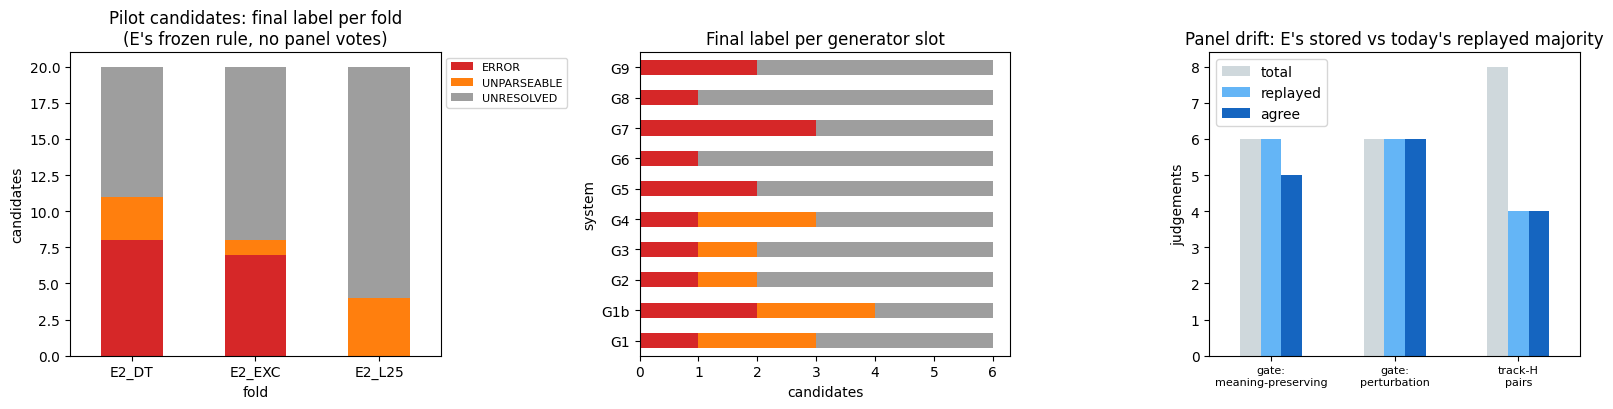

INPUT : {"text": "If Uriah is either environmentally negligent or cares about wildlife (but not both), then he makes green choices.", "candidate_fol": "(EnvironmentallyNegligent(uriah) ⊕ CaresAbout(uriah, wildlife)) → MakesGreenChoices(uriah)", "system": "G1b:meta-llama/llama-3.3-70b-instruct", "prompt_variant": "fewshot_v1"}
REF   : (environmentally_negligent(Uriah) ⊕ cares_about_wildlife(Uriah)) → makes_green_choices(Uriah)
LABEL : ERROR | tier A_unaudited_ref | error ops ['ADD', 'DROP']


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) final labels per fold
colors = {"ERROR": "#d62728", "UNRESOLVED": "#9e9e9e", "UNPARSEABLE": "#ff7f0e", "CORRECT": "#2ca02c"}
lab.plot(kind="bar", stacked=True, ax=axes[0], color=[colors.get(c, "#1f77b4") for c in lab.columns], rot=0)
axes[0].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
axes[0].set_title("Pilot candidates: final label per fold\n(E's frozen rule, no panel votes)")
axes[0].set_ylabel("candidates")

# (b) final label per generator slot
sl = pd.crosstab(cand["system"], cand["final_label"])
sl.plot(kind="barh", stacked=True, ax=axes[1], color=[colors.get(c, "#1f77b4") for c in sl.columns], legend=False)
axes[1].set_title("Final label per generator slot")
axes[1].set_xlabel("candidates")

# (c) panel drift: replayed vs agreeing judgements per item type
drift["group"] = drift.apply(lambda r: "track-H\npairs" if r["type"] == "trackH" else
                             ("gate:\nmeaning-preserving" if r["gold"] == "FAITHFUL" else "gate:\nperturbation"), axis=1)
dd = drift.groupby("group").agg(total=("item", "size"), replayed=("replayed", "sum"), agree=("agree", "sum"))
dd.plot(kind="bar", ax=axes[2], color=["#cfd8dc", "#64b5f6", "#1565c0"], rot=0)
axes[2].tick_params(axis="x", labelsize=8)
axes[2].set_title("Panel drift: E's stored vs today's replayed majority")
axes[2].set_xlabel("")
axes[2].set_ylabel("judgements")
plt.tight_layout()
plt.show()

# one example candidate row as a metric would see it (input) and the hidden label side (metadata)
ex = next(r for r in G["e2_candidates"] if r["metadata_final_label"] == "ERROR")
print("INPUT :", ex["input"])
print("REF   :", ex["metadata_reference_fol"])
print("LABEL :", ex["output"], "| tier", ex["metadata_label_tier"], "| error ops", ex["metadata_error_ops"])